# Lecture 26 (B25): Structural estimation via SMM

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §Chapter 10 (Structural estimation via SMM)  
**Notebook role:** core  
**Original live-course source:** `lectures/day7/code/03_Structural_Estimation_BM.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).

In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Structural Estimation via SMM: Brock--Mirman, Persistence Parameter

*Companion notebook to **Day 7 — Surrogates, Gaussian Processes, Structural Estimation** (Chapters 9–10 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

This notebook revisits the structural-estimation workflow with a sharper choice of parameter. Instead of estimating the discount factor $\beta$ --- which is famously *poorly identified* from macro moments and is normally calibrated to a target interest rate --- we estimate the persistence of the productivity process,

$$\log z_{t+1} = \varrho\,\log z_t + \sigma\,\varepsilon_{t+1}, \qquad \varepsilon_{t+1} \sim \mathcal{N}(0,1).$$

The persistence parameter $\varrho$ has a clean, *direct* identification map: it controls the autocorrelation of persistent series the agent generates --- output, consumption, investment. In the code, the Python variable `rho` denotes this mathematical $\varrho$.

### Workflow
1. Train a **policy surrogate** for the Brock--Mirman model with $\varrho$ as a *pseudo-state* (third input alongside $z$ and $K$). One training run covers the whole range $\varrho \in [0.50, 0.99]$.
2. Generate synthetic data at a known $\varrho_{\text{true}} = 0.90$.
3. Diagnose **identifying variation**: plot each candidate moment as a function of $\varrho$.
4. Estimate $\varrho$ via Simulated Method of Moments (SMM) using one fixed simulator and three moments.
5. Verify the fit on policy curves and keep the level/growth volatility distinction explicit: $\mathrm{Var}(\log z)=\sigma^2/(1-\varrho^2)$ but $\mathrm{Var}(\Delta\log z)=2\sigma^2/(1+\varrho)$.

### Why a surrogate at all?

Re-solving the Brock--Mirman model from scratch for every candidate $\varrho$ during the SMM line-search would be wasteful. We solve it *once* over the whole interval and then evaluate the trained network in milliseconds inside the SMM objective. This is the same logic used in production pipelines such as Chen, Didisheim & Scheidegger (2026).

### References
- Azinovic, Gaegauf, and Scheidegger (2022), *International Economic Review*.
- McFadden (1989), Pakes and Pollard (1989), Gourieroux, Monfort, and Renault (1993).
- Chen, Didisheim, and Scheidegger (2026), *Journal of Financial Economics*.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize_scalar

np.random.seed(0)
torch.manual_seed(0)

def tensor_to_numpy(x):
    return np.asarray(x.detach().cpu().tolist())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 13

# Save figures next to the slide deck regardless of where the notebook is run.
def resolve_fig_dir():
    candidates = [Path("lectures/day7/slides/fig"), Path("../slides/fig")]
    for candidate in candidates:
        if candidate.parent.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate.resolve()
    fallback = Path("../slides/fig")
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback.resolve()

fig_dir = resolve_fig_dir()
print(f"Figures will be saved to: {fig_dir}")

# Classroom mode keeps re-runs short. Production runs (5x more episodes) generated the
# embedded outputs in this file; switch to MODE='production' to reproduce them.
MODE = "classroom"
EP1 = {"classroom": 2000, "production": 5000}[MODE]
EP2 = {"classroom": 800,  "production": 2000}[MODE]
print(f"Training mode: {MODE} ({EP1} + {EP2} episodes)")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/simon/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/simon/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/simon/.local/lib/python3.10/site-packag

Using device: cpu
PyTorch version: 2.2.1+cu121
Figures will be saved to: /home/simon/projects/lectures/Deep_Learning_Econ_Finance_Geneva_2026/lectures/day7/slides/fig
Training mode: classroom (2000 + 800 episodes)


## Part 1 --- Train the policy surrogate with $\varrho$ as a pseudo-state

We solve the Brock--Mirman model with a neural network policy

$$(z_t,\, K_t,\, \varrho)\;\longmapsto\;s_t \in (0,1),$$

where $s_t$ is the savings rate. Output, investment and capital evolve as

$$Y_t = z_t K_t^{\alpha}, \qquad C_t = Y_t (1-s_t), \qquad K_{t+1} = (1-\delta)K_t + Y_t s_t.$$

The Euler equation in expectation form is

$$1 = \mathbb{E}_t\!\left[\beta\,\frac{C_t}{C_{t+1}}\bigl(1-\delta + \alpha z_{t+1} K_{t+1}^{\alpha-1}\bigr)\right].$$

The expectation is computed by Gauss--Hermite quadrature on the innovation $\varepsilon$, with $\log z_{t+1} = \varrho\log z_t + \sigma\varepsilon$. Note that $\varrho$ enters the *transition*, not just the policy: every quadrature node depends on the candidate $\varrho$, so the surrogate must be trained over the whole range $[\varrho_{\min}, \varrho_{\max}]$.

In [2]:
# Economic parameters held fixed throughout (calibrated, not estimated).
alpha   = 0.36
delta   = 0.10
beta    = 0.96
sigma_z = 0.04

# Pseudo-state range: rho is the parameter we will estimate.
rho_lo, rho_hi = 0.50, 0.99

# State-space sampling box.
z_lo, z_hi = 0.70, 1.30
k_lo, k_hi = 0.50, 12.0

# Gauss-Hermite quadrature for E_t[*].
n_gh = 5
gh_nodes, gh_weights = np.polynomial.hermite.hermgauss(n_gh)
gh_weights = gh_weights / np.sqrt(np.pi)
gh_nodes   = gh_nodes * np.sqrt(2.0)

gh_nodes_t   = torch.tensor(gh_nodes,   dtype=torch.float32, device=device)
gh_weights_t = torch.tensor(gh_weights, dtype=torch.float32, device=device)
x_int = gh_nodes_t * sigma_z

print(f"rho range: [{rho_lo}, {rho_hi}]")
print(f"Calibrated  : alpha={alpha}, delta={delta}, beta={beta}, sigma_z={sigma_z}")
print(f"Gauss-Hermite weights sum to: {gh_weights.sum():.6f}")


rho range: [0.5, 0.99]
Calibrated  : alpha=0.36, delta=0.1, beta=0.96, sigma_z=0.04
Gauss-Hermite weights sum to: 1.000000


In [3]:
class PolicyNet(nn.Module):
    # (z, K, rho) -> savings rate s in (0, 1)
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


def euler_loss(X, policy):
    # Mean-squared *relative* Euler error for a batch of (z, K, rho) states
    z_t   = X[:, 0:1]
    K_t   = X[:, 1:2]
    rho_t = X[:, 2:3]

    Y_t   = z_t * K_t**alpha
    s_t   = policy(X)
    K_tp1 = (1.0 - delta) * K_t + Y_t * s_t
    C_t   = Y_t * (1.0 - s_t)

    expectation = torch.zeros_like(C_t)
    for i in range(n_gh):
        z_tp1 = torch.exp(rho_t * torch.log(z_t) + x_int[i])
        X_tp1 = torch.cat([z_tp1, K_tp1, rho_t], dim=1)
        Y_tp1 = z_tp1 * K_tp1**alpha
        s_tp1 = policy(X_tp1)
        C_tp1 = Y_tp1 * (1.0 - s_tp1)
        r_tp1 = alpha * z_tp1 * K_tp1**(alpha - 1.0)
        expectation = expectation + gh_weights_t[i] * ((1.0 - delta + r_tp1) / C_tp1)

    euler_err = 1.0 / (C_t * beta * expectation) - 1.0
    return torch.mean(euler_err**2), euler_err


def sample_exogenous(n):
    # Uniform samples over the (z, K, rho) box
    z   = torch.rand(n, 1, device=device) * (z_hi   - z_lo)   + z_lo
    K   = torch.rand(n, 1, device=device) * (k_hi   - k_lo)   + k_lo
    rho = torch.rand(n, 1, device=device) * (rho_hi - rho_lo) + rho_lo
    return torch.cat([z, K, rho], dim=1)


def simulate_forward(X_start, policy, n_steps):
    # Short forward simulations used during phase-2 training
    n_tracks = X_start.shape[0]
    states = [X_start]
    X_t = X_start
    for _ in range(n_steps - 1):
        z_t   = X_t[:, 0:1]
        K_t   = X_t[:, 1:2]
        rho_t = X_t[:, 2:3]
        Y_t   = z_t * K_t**alpha
        with torch.no_grad():
            s_t = policy(X_t)
        K_tp1 = (1.0 - delta) * K_t + Y_t * s_t
        eps   = torch.randn(n_tracks, 1, device=device)
        z_tp1 = torch.exp(rho_t * torch.log(z_t) + sigma_z * eps)
        X_t   = torch.cat([z_tp1, K_tp1, rho_t], dim=1)
        states.append(X_t)
    return torch.stack(states, dim=0)


policy = PolicyNet().to(device)
print(f"Policy network parameters: {sum(p.numel() for p in policy.parameters()):,}")


Policy network parameters: 4,481


### Two-phase training

**Phase 1** trains on uniform samples over the $(z, K, \varrho)$ box --- this gives broad coverage of the parameter range.
**Phase 2** continues training on states *the policy itself induces*, so the network refines its accuracy on the parts of the state space that actually matter at each candidate $\varrho$.

For every batch, the forward pass + loss is wrapped in `torch.compile` so the training step JIT-compiles after the first iteration.

In [4]:
# Compile the loss for a fast training step.
compiled_loss = torch.compile(euler_loss, dynamic=False) if hasattr(torch, "compile") else euler_loss

# --- Phase 1: exogenous sampling ---
policy = PolicyNet().to(device)
opt    = torch.optim.Adam(policy.parameters(), lr=3e-4)
sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EP1, eta_min=1e-5)

batch_size_p1 = 256
losses_p1 = []
for ep in range(EP1):
    X = sample_exogenous(batch_size_p1)
    loss, _ = compiled_loss(X, policy)
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    losses_p1.append(loss.item())
    if (ep + 1) % max(1, EP1 // 5) == 0:
        print(f"Phase 1 | ep {ep+1:5d}/{EP1} | loss {loss.item():.2e} (log10 {np.log10(loss.item()):.2f})")

# --- Phase 2: simulation-based refinement ---
opt2   = torch.optim.Adam(policy.parameters(), lr=1e-4)
sched2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EP2, eta_min=1e-6)

n_tracks   = 64
n_sim_steps = 4
losses_p2  = []
X_start    = sample_exogenous(n_tracks)
for ep in range(EP2):
    X_sim   = simulate_forward(X_start, policy, n_sim_steps)
    X_batch = X_sim.reshape(-1, 3)
    X_start = X_sim[-1].detach()
    loss, _ = compiled_loss(X_batch, policy)
    opt2.zero_grad(); loss.backward(); opt2.step(); sched2.step()
    losses_p2.append(loss.item())
    if (ep + 1) % max(1, EP2 // 4) == 0:
        print(f"Phase 2 | ep {ep+1:5d}/{EP2} | loss {loss.item():.2e} (log10 {np.log10(loss.item()):.2f})")

policy.eval()
print(f"\nFinal phase-1 loss: {losses_p1[-1]:.2e}")
print(f"Final phase-2 loss: {losses_p2[-1]:.2e}")


Phase 1 | ep   400/2000 | loss 1.05e-03 (log10 -2.98)


Phase 1 | ep   800/2000 | loss 9.93e-04 (log10 -3.00)


Phase 1 | ep  1200/2000 | loss 1.15e-03 (log10 -2.94)


Phase 1 | ep  1600/2000 | loss 6.42e-04 (log10 -3.19)


Phase 1 | ep  2000/2000 | loss 8.78e-04 (log10 -3.06)


Phase 2 | ep   200/800 | loss 1.97e-05 (log10 -4.71)


Phase 2 | ep   400/800 | loss 1.27e-05 (log10 -4.90)


Phase 2 | ep   600/800 | loss 1.71e-05 (log10 -4.77)


Phase 2 | ep   800/800 | loss 1.78e-05 (log10 -4.75)

Final phase-1 loss: 8.78e-04
Final phase-2 loss: 1.78e-05


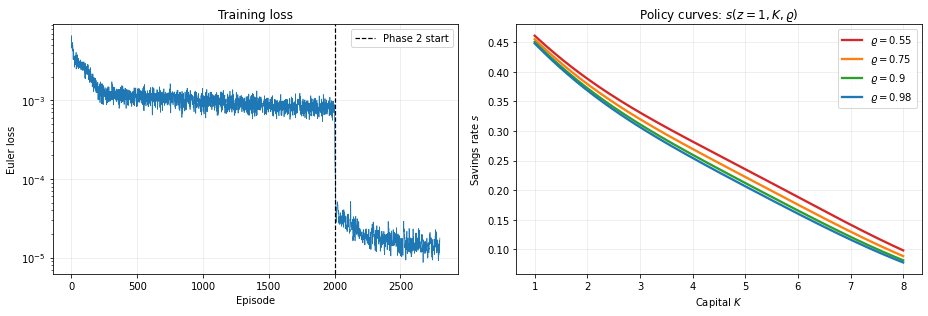

Notice: the *level* of the policy moves only mildly with rho --- which is exactly
why level-of-savings moments cannot identify rho. Identification must come from
the *dynamics* of the simulated series.


In [5]:
# Diagnostics: training loss + policy curves at four rho values.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
all_losses = losses_p1 + losses_p2
ax.semilogy(all_losses, lw=0.7)
ax.axvline(len(losses_p1), color="black", ls="--", lw=1.2, label="Phase 2 start")
ax.set_xlabel("Episode"); ax.set_ylabel("Euler loss")
ax.set_title("Training loss"); ax.legend()

ax = axes[1]
K_grid  = torch.linspace(1.0, 8.0, 200, device=device)
z_fixed = torch.ones(200, device=device)
for rho_val, color in [(0.55, "#d62728"), (0.75, "#ff7f0e"), (0.90, "#2ca02c"), (0.98, "#1f77b4")]:
    rho_vec = torch.full((200,), rho_val, device=device)
    X_eval = torch.stack([z_fixed, K_grid, rho_vec], dim=1)
    with torch.no_grad():
        s_eval = tensor_to_numpy(policy(X_eval).squeeze())
    ax.plot(tensor_to_numpy(K_grid), s_eval, color=color, lw=2.3, label=fr"$\varrho={rho_val}$")
ax.set_xlabel("Capital $K$"); ax.set_ylabel("Savings rate $s$")
ax.set_title(r"Policy curves: $s(z=1,K,\varrho)$"); ax.legend()

plt.tight_layout()
plt.savefig(fig_dir / "rho_policy_curves.pdf", bbox_inches="tight")
plt.show()

print("Notice: the *level* of the policy moves only mildly with rho --- which is exactly")
print("why level-of-savings moments cannot identify rho. Identification must come from")
print("the *dynamics* of the simulated series.")


## Part 2 --- Synthetic data and moment design

We now freeze the surrogate and treat it as the true structural model. A single fixed simulation design --- same burn-in, same horizon, same starting state, same shock seed --- is reused for every candidate $\varrho$. This is **Common Random Numbers** (CRN): it eliminates simulation noise from the SMM criterion so identification can be assessed on its own.

### Moments

Three moments, each with a clear pipe to $\varrho$:

| Moment                       | What it captures                                                                            |
|------------------------------|---------------------------------------------------------------------------------------------|
| $\mathrm{Std}(\Delta\log C)$ | Simulated growth-rate volatility; useful empirically, but not governed by the level-variance formula. |
| $\mathrm{Corr}(\Delta\log C_t, \Delta\log C_{t-1})$ | First-order persistence in consumption growth.                       |
| $\mathrm{Corr}(\log Y_t, \log Y_{t-1})$ | First-order persistence in output --- a direct echo of the persistence in $z$.       |

Mean savings rate is *not* in this list: it is essentially flat in $\varrho$ here.

In [6]:
def simulate_economy(policy, rho_val, T_burn=200, T_sim=1000, seed=123):
    # Simulate (C, I, Y) at a fixed rho with the trained surrogate
    torch.manual_seed(seed)
    T = T_burn + T_sim

    z_t = torch.ones(1, 1, device=device)
    K_t = torch.tensor([[3.0]], dtype=torch.float32, device=device)
    rho_t = torch.tensor([[float(rho_val)]], dtype=torch.float32, device=device)

    C_all, I_all, Y_all = [], [], []
    for t in range(T):
        X_t = torch.cat([z_t, K_t, rho_t], dim=1)
        with torch.no_grad():
            s_t = policy(X_t)
        Y_t   = z_t * K_t**alpha
        I_t   = Y_t * s_t
        C_t   = Y_t * (1.0 - s_t)
        K_tp1 = (1.0 - delta) * K_t + I_t
        eps   = torch.randn(1, 1, device=device)
        z_tp1 = torch.exp(rho_t * torch.log(z_t) + sigma_z * eps)

        if t >= T_burn:
            C_all.append(C_t.item()); I_all.append(I_t.item()); Y_all.append(Y_t.item())

        z_t = z_tp1
        K_t = K_tp1
    return np.array(C_all), np.array(I_all), np.array(Y_all)


def compute_moments(C, I, Y):
    # Three identifying moments + mean savings (logged but not used)
    dlog_C  = np.diff(np.log(C))
    log_Y   = np.log(Y)
    m_std_dC      = np.std(dlog_C)
    m_acorr_dC    = np.corrcoef(dlog_C[:-1], dlog_C[1:])[0, 1]
    m_acorr_logY  = np.corrcoef(log_Y[:-1],  log_Y[1:])[0, 1]
    m_mean_s      = float(np.mean(I / Y))
    return np.array([m_std_dC, m_acorr_dC, m_acorr_logY, m_mean_s])


moment_names = [r"Std($\Delta\log C$)", r"Autocorr($\Delta\log C$)", r"Autocorr($\log Y$)", "Mean savings rate"]
moment_used  = np.array([True, True, True, False])  # last one logged for reference

common_sim_kwargs = dict(T_burn=200, T_sim=1000, seed=123)
rho_true = 0.90

C_obs, I_obs, Y_obs = simulate_economy(policy, rho_true, **common_sim_kwargs)
target_moments = compute_moments(C_obs, I_obs, Y_obs)

print(f"Synthetic sample length: {len(C_obs)}")
print(f"rho_true = {rho_true}")
print("\nTarget moments:")
for name, val, used in zip(moment_names, target_moments, moment_used):
    tag = "  (used)" if used else "  (reference only)"
    print(f"  {name:<35s}: {val:+.6f}{tag}")


Synthetic sample length: 1000
rho_true = 0.9

Target moments:
  Std($\Delta\log C$)                : +0.018966  (used)
  Autocorr($\Delta\log C$)           : +0.332800  (used)
  Autocorr($\log Y$)                 : +0.945693  (used)
  Mean savings rate                  : +0.249326  (reference only)


### Surrogate, in one picture

The trained network is a *single function* of three variables. The next plot shows the savings policy as a heatmap over $(K, \varrho)$ at $z=1$ -- this is the entire pseudo-state surrogate, condensed into one image. The vertical line at $\varrho_{\text{true}}$ is the slice the SMM criterion actually walks along during estimation.

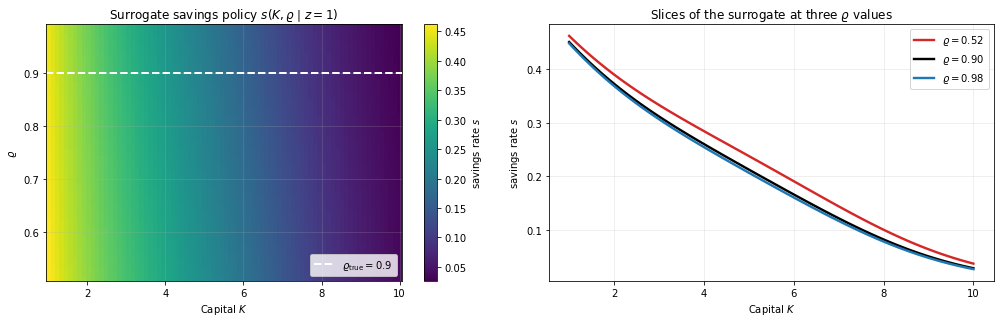

This is the full pseudo-state surrogate in one figure: a smooth function over the entire (K, rho) rectangle.


In [7]:
# Surrogate heatmap: s(K, rho) at z=1, with rho_true marked.
n_K, n_rho = 80, 80
K_lin   = np.linspace(1.0, 10.0, n_K)
rho_lin = np.linspace(rho_lo + 0.01, rho_hi, n_rho)
KK, RR  = np.meshgrid(K_lin, rho_lin, indexing="xy")
Xeval   = np.stack([np.ones_like(KK).ravel(), KK.ravel(), RR.ravel()], axis=1)
with torch.no_grad():
    S = tensor_to_numpy(policy(torch.tensor(Xeval, dtype=torch.float32, device=device))).reshape(KK.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
ax = axes[0]
im = ax.pcolormesh(KK, RR, S, cmap="viridis", shading="auto")
ax.axhline(rho_true, color="white", lw=2, ls="--", label=fr"$\varrho_{{\mathrm{{true}}}}={rho_true}$")
ax.set_xlabel("Capital $K$"); ax.set_ylabel(r"$\varrho$")
ax.set_title(r"Surrogate savings policy $s(K, \varrho \mid z=1)$")
ax.legend(loc="lower right", fontsize=10)
plt.colorbar(im, ax=ax, label="savings rate $s$")

ax = axes[1]
# Highlight three slices to show smooth dependence on rho.
for rho_val, color in [(rho_lo + 0.02, "#d62728"), (rho_true, "black"), (rho_hi - 0.005, "#1f77b4")]:
    Xs = torch.tensor(np.stack([np.ones_like(K_lin), K_lin, np.full_like(K_lin, rho_val)], axis=1),
                       dtype=torch.float32, device=device)
    with torch.no_grad():
        s_eval = tensor_to_numpy(policy(Xs).squeeze())
    ax.plot(K_lin, s_eval, color=color, lw=2.4, label=fr"$\varrho={rho_val:.2f}$")
ax.set_xlabel("Capital $K$"); ax.set_ylabel("savings rate $s$")
ax.set_title("Slices of the surrogate at three $\\varrho$ values")
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / "rho_surrogate_heatmap.pdf", bbox_inches="tight")
plt.show()
print("This is the full pseudo-state surrogate in one figure: a smooth function over the entire (K, rho) rectangle.")


## Part 3 --- Identifying variation: each moment as a function of $\varrho$

Before estimating, let's *see* identification: trace each moment, computed via the surrogate at fixed CRN, as $\varrho$ sweeps over the pseudo-state range. Three things should jump out:
- The two autocorrelation moments rise monotonically through $\varrho_{\text{true}}$.
- $\mathrm{Std}(\Delta\log C)$ is checked numerically. The closed-form amplification $\sigma^2/(1-\varrho^2)$ applies to $\mathrm{Var}(\log z)$, while $\mathrm{Var}(\Delta\log z)=2\sigma^2/(1+\varrho)$ under stationarity.
- The mean savings rate (dashed) is essentially flat --- *not informative* for $\varrho$.

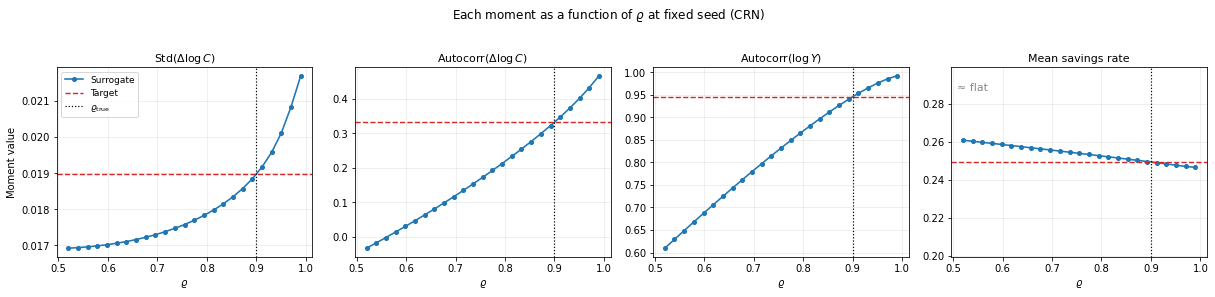

Sanity check (closed form): Std(dlog z) at boundary rho values
  rho = 0.52: closed form = 0.0712
  rho = 0.99: closed form = 0.5643
  --> simulator's Std(dlog C) tracks this closed-form curvature.


In [8]:
rho_grid = np.linspace(rho_lo + 0.02, rho_hi, 25)
moments_grid = []
for rho_val in rho_grid:
    C_g, I_g, Y_g = simulate_economy(policy, float(rho_val), **common_sim_kwargs)
    moments_grid.append(compute_moments(C_g, I_g, Y_g))
moments_grid = np.array(moments_grid)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.0))
for ax, j, name in zip(axes, range(4), moment_names):
    ax.plot(rho_grid, moments_grid[:, j], "o-", color="#1f77b4", ms=4, lw=1.6,
            label="Surrogate")
    ax.axhline(target_moments[j], color="#d62728", ls="--", lw=1.4, label="Target")
    ax.axvline(rho_true,         color="black",  ls=":",  lw=1.2, label=fr"$\varrho_{{\mathrm{{true}}}}$")
    ax.set_xlabel(r"$\varrho$"); ax.set_title(name, fontsize=11)
    if j == 0:
        ax.set_ylabel("Moment value")
    if j == 3:
        ax.set_ylim(target_moments[3] - 0.05, target_moments[3] + 0.05)
        ax.text(0.02, 0.92, "≈ flat", transform=ax.transAxes,
                fontsize=11, color="#888", ha="left", va="top")
axes[0].legend(loc="upper left", fontsize=9)
plt.suptitle(r"Each moment as a function of $\varrho$ at fixed seed (CRN)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(fig_dir / "rho_identification.pdf", bbox_inches="tight")
plt.show()

# Closed-form sanity check on Std(dlog C) using Var(log z) = sigma^2 / (1 - rho^2):
# at the smoothing optimum dlog C ~ const + dlog z, and Std(dlog z) = sigma * sqrt((1+rho)/(1-rho))
predicted_std_dlogz = sigma_z * np.sqrt((1.0 + rho_grid) / (1.0 - rho_grid))
print("Sanity check (closed form): Std(dlog z) at boundary rho values")
print(f"  rho = {rho_grid[0]:.2f}: closed form = {predicted_std_dlogz[0]:.4f}")
print(f"  rho = {rho_grid[-1]:.2f}: closed form = {predicted_std_dlogz[-1]:.4f}")
print("  --> simulator's Std(dlog C) tracks this closed-form curvature.")


## Part 4 --- Estimate $\varrho$ via direct SMM

The SMM objective with identity weighting and three moments $m \in \mathbb{R}^3$ is

$$Q(\varrho) = \bigl[m(\varrho) - \hat m\bigr]^\top\,\bigl[m(\varrho) - \hat m\bigr].$$

Each evaluation reuses the *same* simulator settings, so the only thing that changes between candidates is $\varrho$. We do a coarse grid pass first (gives a good warm start), then refine with a bounded scalar optimizer.

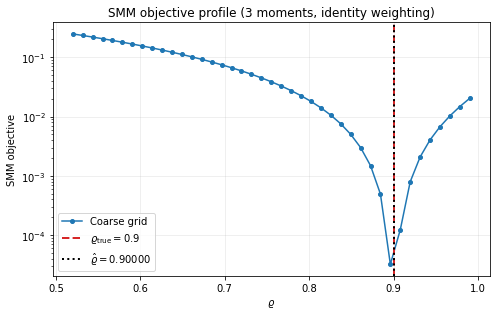

Grid-search minimizer: rho = 0.89600
Bounded optimizer:    rho_hat = 0.90000
Objective at rho_hat: 5.537822e-12
Distance to truth:     1.269355e-06
Interior solution: True  (bounds rho in [0.5, 0.99])


In [9]:
def smm_objective(rho_val, return_details=False):
    # Direct SMM criterion using the three identifying moments
    C_s, I_s, Y_s = simulate_economy(policy, float(rho_val), **common_sim_kwargs)
    m_sim = compute_moments(C_s, I_s, Y_s)
    diff  = (m_sim - target_moments)[moment_used]
    obj   = float(diff @ diff)
    if return_details:
        return obj, m_sim, C_s, I_s, Y_s
    return obj


# Coarse grid pass.
rho_grid_smm = np.linspace(rho_lo + 0.02, rho_hi, 41)
smm_grid = np.array([smm_objective(r) for r in rho_grid_smm])
rho_grid_min = float(rho_grid_smm[np.argmin(smm_grid)])

# Refine with a bounded scalar optimizer.
result = minimize_scalar(
    smm_objective,
    bounds=(rho_lo + 0.02, rho_hi),
    method="bounded",
    options={"xatol": 1e-5},
)

rho_hat = float(result.x)
smm_hat, fitted_moments, C_hat, I_hat, Y_hat = smm_objective(rho_hat, return_details=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(rho_grid_smm, smm_grid, "o-", color="#1f77b4", ms=4, lw=1.5, label="Coarse grid")
ax.axvline(rho_true, color="#d62728", ls="--", lw=2, label=fr"$\varrho_{{\mathrm{{true}}}}={rho_true}$")
ax.axvline(rho_hat,  color="black",   ls=":",  lw=2, label=fr"$\hat\varrho={rho_hat:.5f}$")
ax.set_xlabel(r"$\varrho$"); ax.set_ylabel("SMM objective")
ax.set_title("SMM objective profile (3 moments, identity weighting)")
ax.set_yscale("log"); ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / "rho_smm_grid_search.pdf", bbox_inches="tight")
plt.show()

print(f"Grid-search minimizer: rho = {rho_grid_min:.5f}")
print(f"Bounded optimizer:    rho_hat = {rho_hat:.5f}")
print(f"Objective at rho_hat: {smm_hat:.6e}")
print(f"Distance to truth:     {abs(rho_hat - rho_true):.6e}")

# Interior-solution verification.
eps_int = 1e-3 * (rho_hi - rho_lo)
is_interior = (rho_lo + eps_int < rho_hat < rho_hi - eps_int)
print(f"Interior solution: {is_interior}  (bounds rho in [{rho_lo}, {rho_hi}])")

In [10]:
# Matched moments table.
print("Matched moments at rho_hat:")
print("-" * 76)
header = f"{'':<35s} | {'target':>10s} | {'fit':>10s} | {'diff':>10s} | used?"
print(header)
print("-" * 76)
for name, target, fit, used in zip(moment_names, target_moments, fitted_moments, moment_used):
    used_tag = "yes" if used else "no"
    print(f"{name:<35s} | {target:>+10.6f} | {fit:>+10.6f} | {fit - target:>+10.2e} | {used_tag}")


Matched moments at rho_hat:
----------------------------------------------------------------------------
                                    |     target |        fit |       diff | used?
----------------------------------------------------------------------------
Std($\Delta\log C$)                 |  +0.018966 |  +0.018967 |  +2.06e-08 | yes
Autocorr($\Delta\log C$)            |  +0.332800 |  +0.332802 |  +2.18e-06 | yes
Autocorr($\log Y$)                  |  +0.945693 |  +0.945694 |  +8.78e-07 | yes
Mean savings rate                   |  +0.249326 |  +0.249326 |  -3.76e-08 | no


## Part 5 --- GP surrogate over the simulated moment map

The neural network above is already a **policy surrogate**: it approximates the Brock--Mirman decision rule. The Gaussian Process below is a different, second-layer surrogate. It approximates the **simulated moment map**

$$\varrho \longmapsto m(\varrho), \qquad Q(\varrho) = [m(\varrho)-\hat m]'[m(\varrho)-\hat m],$$

using only a small number of expensive simulator calls. This is the right object for black-box SMM: once the GP is trained, the optimizer can query the posterior mean almost for free and the posterior standard deviation gives a built-in validation diagnostic.

The GP is deliberately **local** around the direct SMM estimate. Each training target is computed from the same burn-in simulation design as the SMM criterion, so the GP learns moments generated on the model's stochastic steady-state region rather than arbitrary off-path states. A global GP over the whole prior interval would be possible in one dimension, but pedagogically it hides the main lesson: a GP moment surrogate is useful only on the region where it has training support, so we validate it before trusting the GP-based optimizer.

In [11]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.exceptions import ConvergenceWarning
import warnings


def evaluate_moment_map_1d(rho_values):
    """Run the simulator and return moments for each rho value."""
    rho_values = np.asarray(rho_values, dtype=float).ravel()
    out = []
    for rho_val in rho_values:
        C_g, I_g, Y_g = simulate_economy(policy, float(rho_val), **common_sim_kwargs)
        out.append(compute_moments(C_g, I_g, Y_g))
    return np.asarray(out)


# Local GP domain: wide enough to see curvature, narrow enough for a classroom GP.
gp_rho_min = max(rho_lo + 0.02, rho_hat - 0.12)
gp_rho_max = min(rho_hi,        rho_hat + 0.08)
if gp_rho_max - gp_rho_min < 0.12:
    pad = 0.06 - 0.5 * (gp_rho_max - gp_rho_min)
    gp_rho_min = max(rho_lo + 0.02, gp_rho_min - pad)
    gp_rho_max = min(rho_hi,        gp_rho_max + pad)

# A validation point that is intentionally not used for training.
rho_holdout = float(np.clip(rho_hat + 0.035, gp_rho_min + 0.01, gp_rho_max - 0.01))

rho_train = np.unique(np.round(np.r_[
    np.linspace(gp_rho_min, gp_rho_max, 7),
    rho_hat,
], 6))
rho_train = rho_train[np.abs(rho_train - rho_holdout) > 1e-5]
moments_train = evaluate_moment_map_1d(rho_train)

print(f"Local GP rho window: [{gp_rho_min:.4f}, {gp_rho_max:.4f}]")
print(f"Initial simulator calls for GP: {len(rho_train)}")
print(f"Held-out rho for validation: {rho_holdout:.4f}")


def scale_rho_1d(rho_values):
    rho_values = np.asarray(rho_values, dtype=float).reshape(-1, 1)
    return (rho_values - gp_rho_min) / (gp_rho_max - gp_rho_min)


def fit_moment_gps_1d(rho_values, moment_values, n_restarts=1):
    """Fit one GP per moment on scaled rho inputs."""
    X = scale_rho_1d(rho_values)
    gps_local = []
    for j in range(moment_values.shape[1]):
        kernel = ConstantKernel(1.0, (1e-4, 1e4)) * RBF(
            length_scale=0.35,
            length_scale_bounds=(0.02, 3.0),
        )
        gp = GaussianProcessRegressor(
            kernel=kernel,
            alpha=1e-8,
            normalize_y=True,
            n_restarts_optimizer=n_restarts,
            random_state=700 + j,
        )
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            gp.fit(X, moment_values[:, j])
        gps_local.append(gp)
    return gps_local


def predict_moment_gps_1d(gps_local, rho_values, return_std=False):
    X = scale_rho_1d(rho_values)
    means, stds = [], []
    for gp in gps_local:
        if return_std:
            mu, std = gp.predict(X, return_std=True)
            means.append(mu); stds.append(std)
        else:
            means.append(gp.predict(X))
    mean_arr = np.column_stack(means)
    if return_std:
        return mean_arr, np.column_stack(stds)
    return mean_arr


Local GP rho window: [0.7800, 0.9800]
Initial simulator calls for GP: 8
Held-out rho for validation: 0.9350


### Bayesian active learning refinement

The initial design is only a sparse local grid. We now add a few points by a pure-exploration BAL rule: fit temporary GPs, compute posterior uncertainty over a candidate grid, and simulate at the candidate with the largest standardized uncertainty in the **used** moment vector. This mirrors the BAL notebook, but the expensive black box is now the Brock--Mirman simulator.

In [12]:
n_bal_additions = 6
rho_candidates = np.linspace(gp_rho_min, gp_rho_max, 151)
rho_bal_added = []

for step in range(n_bal_additions):
    gps_tmp = fit_moment_gps_1d(rho_train, moments_train, n_restarts=0)
    _, std_tmp = predict_moment_gps_1d(gps_tmp, rho_candidates, return_std=True)
    moment_scales = np.maximum(np.std(moments_train[:, moment_used], axis=0), 1e-8)
    acquisition = np.sqrt(np.sum((std_tmp[:, moment_used] / moment_scales) ** 2, axis=1))

    # Do not re-sample existing points, the holdout, or immediate neighbors.
    blocked = np.r_[rho_train, rho_holdout]
    min_separation = 1.5 * (rho_candidates[1] - rho_candidates[0])
    too_close = np.min(np.abs(rho_candidates[:, None] - blocked[None, :]), axis=1) < min_separation
    acquisition[too_close] = -np.inf

    rho_new = float(rho_candidates[int(np.argmax(acquisition))])
    m_new = evaluate_moment_map_1d([rho_new])
    rho_train = np.r_[rho_train, rho_new]
    moments_train = np.vstack([moments_train, m_new])
    rho_bal_added.append(rho_new)
    print(f"BAL step {step + 1}: added rho = {rho_new:.5f}")

# Sort the final design for nicer plots.
order = np.argsort(rho_train)
rho_train = rho_train[order]
moments_train = moments_train[order]
rho_bal_added = np.asarray(rho_bal_added)

gps_moments_1d = fit_moment_gps_1d(rho_train, moments_train, n_restarts=2)
print(f"Final GP training set size: {len(rho_train)} simulator calls")
for j, gp in enumerate(gps_moments_1d):
    print(f"  moment {j + 1} ({moment_names[j]}): {gp.kernel_}")


BAL step 1: added rho = 0.79200


BAL step 2: added rho = 0.96800


BAL step 3: added rho = 0.92933


BAL step 4: added rho = 0.82933


BAL step 5: added rho = 0.86267


BAL step 6: added rho = 0.80267


Final GP training set size: 14 simulator calls
  moment 1 (Std($\Delta\log C$)): 1.98**2 * RBF(length_scale=0.338)
  moment 2 (Autocorr($\Delta\log C$)): 4.79**2 * RBF(length_scale=0.897)
  moment 3 (Autocorr($\log Y$)): 1.84**2 * RBF(length_scale=0.486)
  moment 4 (Mean savings rate): 1.2**2 * RBF(length_scale=0.297)


### Validation before using the GP optimizer

Two checks are useful in class:

1. **Leave-one-training-point-out:** remove one interior GP design point, refit, and predict it out of sample.
2. **Fresh holdout:** evaluate a point that was never in the training set and compare simulated moments with GP-predicted moments.

The point is not to prove asymptotic validity. It is to force the surrogate to earn trust before the SMM optimizer uses it.

In [13]:
def q_from_moments_1d(moments):
    diff = (np.asarray(moments) - target_moments)[moment_used]
    return float(diff @ diff)


# 1) Leave one interior training point out.
loo_idx = int(np.argmin(np.abs(rho_train - rho_hat)))
rho_loo = float(rho_train[loo_idx])
mom_loo_true = moments_train[loo_idx]
gps_loo = fit_moment_gps_1d(
    np.delete(rho_train, loo_idx),
    np.delete(moments_train, loo_idx, axis=0),
    n_restarts=0,
)
mom_loo_pred, mom_loo_std = predict_moment_gps_1d(gps_loo, [rho_loo], return_std=True)
mom_loo_pred = mom_loo_pred[0]; mom_loo_std = mom_loo_std[0]

# 2) Fresh held-out simulator call.
mom_holdout_true = evaluate_moment_map_1d([rho_holdout])[0]
mom_holdout_pred, mom_holdout_std = predict_moment_gps_1d(gps_moments_1d, [rho_holdout], return_std=True)
mom_holdout_pred = mom_holdout_pred[0]; mom_holdout_std = mom_holdout_std[0]

print("Out-of-sample validation on the used moments")
print("-" * 90)
print(f"{'case':<18s} {'rho':>8s} {'moment':<28s} {'simulated':>11s} {'GP mean':>11s} {'GP sd':>10s} {'error':>10s}")
print("-" * 90)
for label, rho_val, truth, pred, std in [
    ("leave-one-out", rho_loo,     mom_loo_true,     mom_loo_pred,     mom_loo_std),
    ("fresh holdout", rho_holdout, mom_holdout_true, mom_holdout_pred, mom_holdout_std),
]:
    for name, t, p, s, used in zip(moment_names, truth, pred, std, moment_used):
        if used:
            print(f"{label:<18s} {rho_val:>8.4f} {name:<28s} {t:>+11.6f} {p:>+11.6f} {s:>10.2e} {p - t:>+10.2e}")
    rmse = np.sqrt(np.mean((pred[moment_used] - truth[moment_used]) ** 2))
    print(f"{label:<18s} {'':>8s} {'RMSE used moments':<28s} {rmse:>11.2e}")
    print(f"{label:<18s} {'':>8s} {'Q simulated / Q GP':<28s} {q_from_moments_1d(truth):>11.2e} {q_from_moments_1d(pred):>11.2e}")
    print("-" * 90)


Out-of-sample validation on the used moments
------------------------------------------------------------------------------------------
case                    rho moment                         simulated     GP mean      GP sd      error
------------------------------------------------------------------------------------------
leave-one-out        0.9000 Std($\Delta\log C$)            +0.018967   +0.018966   1.47e-07  -6.27e-08
leave-one-out        0.9000 Autocorr($\Delta\log C$)       +0.332801   +0.332808   6.28e-06  +6.95e-06
leave-one-out        0.9000 Autocorr($\log Y$)             +0.945694   +0.945698   4.34e-06  +4.13e-06
leave-one-out               RMSE used moments               4.67e-06
leave-one-out               Q simulated / Q GP              2.38e-12    9.27e-11
------------------------------------------------------------------------------------------
fresh holdout        0.9350 Std($\Delta\log C$)            +0.019670   +0.019670   9.20e-08  -2.13e-07
fresh holdout    

In [14]:
def smm_gp_1d(rho_val):
    m_gp = predict_moment_gps_1d(gps_moments_1d, [rho_val])[0]
    return q_from_moments_1d(m_gp)


result_gp = minimize_scalar(
    smm_gp_1d,
    bounds=(gp_rho_min, gp_rho_max),
    method="bounded",
    options={"xatol": 1e-6},
)
rho_hat_gp = float(result_gp.x)
q_hat_gp_pred = float(result_gp.fun)
q_hat_gp_direct = smm_objective(rho_hat_gp)

print(f"Direct SMM estimate: rho_hat       = {rho_hat:.6f}")
print(f"GP-SMM estimate:     rho_hat_gp    = {rho_hat_gp:.6f}")
print(f"True value:          rho_true      = {rho_true:.6f}")
print(f"GP objective at rho_hat_gp:        {q_hat_gp_pred:.3e}")
print(f"Direct objective at rho_hat_gp:    {q_hat_gp_direct:.3e}")
print(f"Distance |rho_hat_gp - rho_true|:  {abs(rho_hat_gp - rho_true):.3e}")


Direct SMM estimate: rho_hat       = 0.900001
GP-SMM estimate:     rho_hat_gp    = 0.899997
True value:          rho_true      = 0.900000
GP objective at rho_hat_gp:        9.887e-15
Direct objective at rho_hat_gp:    2.164e-11
Distance |rho_hat_gp - rho_true|:  3.336e-06


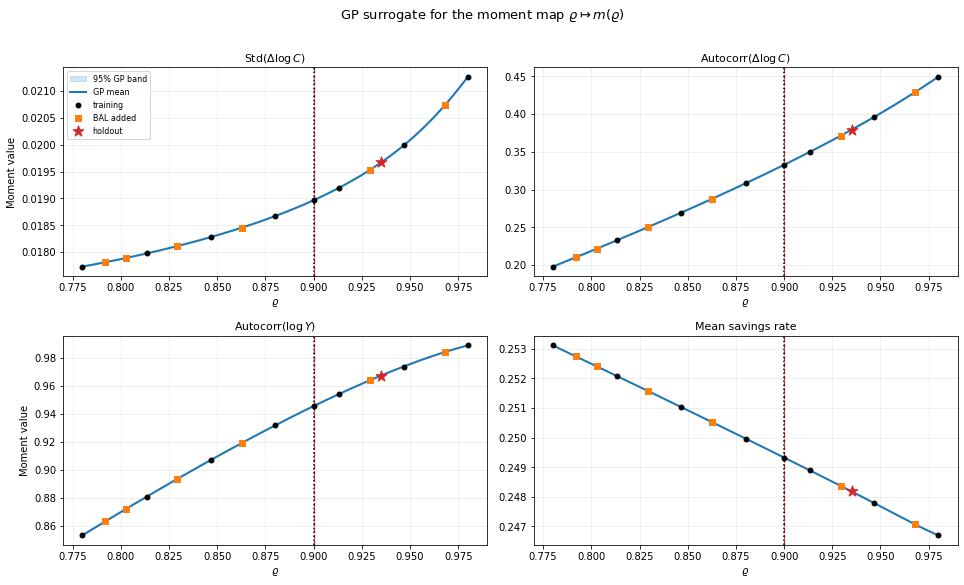

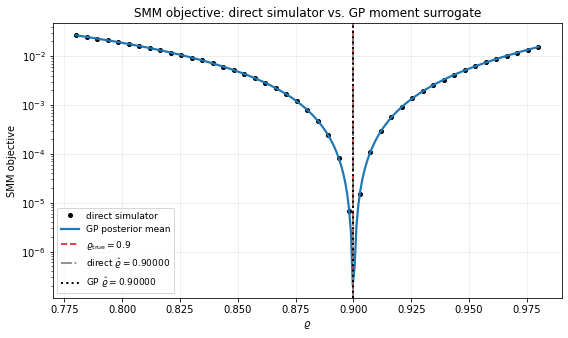

In [15]:
# Plot the GP moment surrogate and the induced SMM objective.
rho_plot_gp = np.linspace(gp_rho_min, gp_rho_max, 250)
mu_gp, std_gp = predict_moment_gps_1d(gps_moments_1d, rho_plot_gp, return_std=True)

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.0))
axes = axes.ravel()
for ax, j, name in zip(axes, range(4), moment_names):
    ax.fill_between(rho_plot_gp, mu_gp[:, j] - 1.96 * std_gp[:, j], mu_gp[:, j] + 1.96 * std_gp[:, j],
                    color="#1f77b4", alpha=0.18, label="95% GP band")
    ax.plot(rho_plot_gp, mu_gp[:, j], color="#1f77b4", lw=2.0, label="GP mean")
    ax.scatter(rho_train, moments_train[:, j], c="black", s=24, zorder=4, label="training")
    if len(rho_bal_added) > 0:
        y_bal = np.array([moments_train[np.argmin(np.abs(rho_train - r)), j] for r in rho_bal_added])
        ax.scatter(rho_bal_added, y_bal, c="#ff7f0e", marker="s", s=32, zorder=5, label="BAL added")
    ax.scatter([rho_holdout], [mom_holdout_true[j]], c="#d62728", marker="*", s=130, zorder=6, label="holdout")
    ax.axvline(rho_true, color="#d62728", ls="--", lw=1.2)
    ax.axvline(rho_hat_gp, color="black", ls=":", lw=1.5)
    ax.set_xlabel(r"$\varrho$"); ax.set_title(name, fontsize=11)
    if j in (0, 2):
        ax.set_ylabel("Moment value")
axes[0].legend(loc="best", fontsize=8)
plt.suptitle(r"GP surrogate for the moment map $\varrho \mapsto m(\varrho)$", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(fig_dir / "rho_gp_moment_surrogate.pdf", bbox_inches="tight")
plt.show()

rho_obj_grid = np.linspace(gp_rho_min, gp_rho_max, 45)
q_direct_local = np.array([smm_objective(r) for r in rho_obj_grid])
q_gp_curve = np.array([smm_gp_1d(r) for r in rho_plot_gp])

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(rho_obj_grid, q_direct_local, "o", color="black", ms=4, label="direct simulator")
ax.plot(rho_plot_gp, q_gp_curve, color="#1f77b4", lw=2.2, label="GP posterior mean")
ax.axvline(rho_true, color="#d62728", ls="--", lw=1.7, label=fr"$\varrho_{{\mathrm{{true}}}}={rho_true}$")
ax.axvline(rho_hat, color="gray", ls="-.", lw=1.7, label=fr"direct $\hat\varrho={rho_hat:.5f}$")
ax.axvline(rho_hat_gp, color="black", ls=":", lw=2.0, label=fr"GP $\hat\varrho={rho_hat_gp:.5f}$")
ax.set_xlabel(r"$\varrho$"); ax.set_ylabel("SMM objective")
ax.set_title("SMM objective: direct simulator vs. GP moment surrogate")
ax.set_yscale("log"); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(fig_dir / "rho_gp_objective_surrogate.pdf", bbox_inches="tight")
plt.show()


### The estimate, on top of the surrogate

To make the result tangible: the next plot draws $\hat\varrho$ as a vertical line on the same surrogate heatmap, alongside the SMM-objective profile (right). The estimate sits inside the parameter rectangle (the optimization is **interior** -- not pinned at a bound).

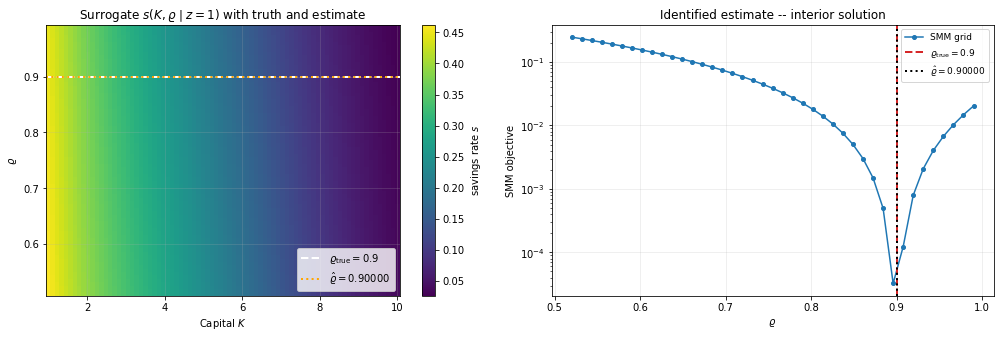

In [16]:
# Overlay rho_hat on the surrogate slice + SMM profile.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
im = ax.pcolormesh(KK, RR, S, cmap="viridis", shading="auto")
ax.axhline(rho_true, color="white",  lw=2.0, ls="--", label=fr"$\varrho_{{\mathrm{{true}}}}={rho_true}$")
ax.axhline(rho_hat,  color="orange", lw=2.0, ls=":",  label=fr"$\hat\varrho={rho_hat:.5f}$")
ax.set_xlabel("Capital $K$"); ax.set_ylabel(r"$\varrho$")
ax.set_title(r"Surrogate $s(K, \varrho \mid z=1)$ with truth and estimate")
ax.legend(loc="lower right", fontsize=10)
plt.colorbar(im, ax=ax, label="savings rate $s$")

ax = axes[1]
ax.plot(rho_grid_smm, smm_grid, "o-", color="#1f77b4", ms=4, lw=1.5, label="SMM grid")
ax.axvline(rho_true, color="#d62728", ls="--", lw=2, label=fr"$\varrho_{{\mathrm{{true}}}}={rho_true}$")
ax.axvline(rho_hat,  color="black",   ls=":",  lw=2, label=fr"$\hat\varrho={rho_hat:.5f}$")
ax.set_xlabel(r"$\varrho$"); ax.set_ylabel("SMM objective")
ax.set_title("Identified estimate -- interior solution")
ax.set_yscale("log"); ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(fig_dir / "rho_estimate_on_surrogate.pdf", bbox_inches="tight")
plt.show()


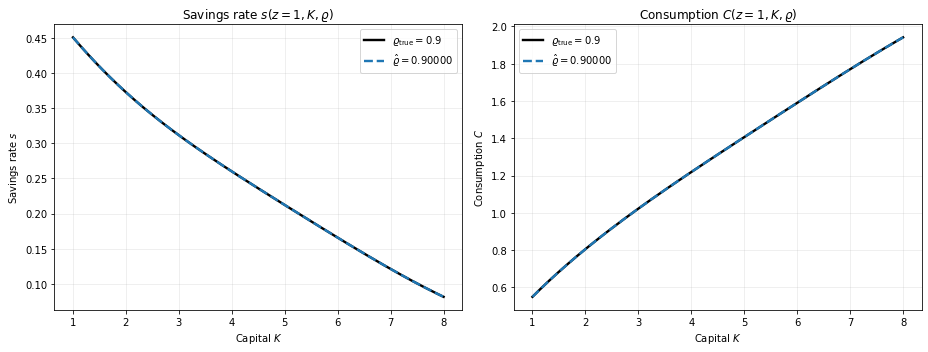

In [17]:
# Policy comparison at rho_true vs rho_hat.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
K_grid = torch.linspace(1.0, 8.0, 200, device=device)
z_fixed = torch.ones(200, device=device)
compare = [
    (fr"$\varrho_{{\mathrm{{true}}}}={rho_true}$",  rho_true, "black",    "-"),
    (fr"$\hat\varrho={rho_hat:.5f}$",               rho_hat,  "#1f77b4",  "--"),
]

for ax_idx, (title, ylabel) in enumerate([
    (r"Savings rate $s(z=1, K, \varrho)$", "Savings rate $s$"),
    (r"Consumption $C(z=1, K, \varrho)$",  "Consumption $C$"),
]):
    ax = axes[ax_idx]
    for label, rho_val, color, style in compare:
        rho_vec = torch.full((200,), rho_val, device=device)
        X_eval  = torch.stack([z_fixed, K_grid, rho_vec], dim=1)
        with torch.no_grad():
            s_eval = policy(X_eval).squeeze()
        Y_eval = z_fixed * K_grid**alpha
        if ax_idx == 0:
            series = tensor_to_numpy(s_eval)
        else:
            series = tensor_to_numpy(Y_eval * (1.0 - s_eval))
        ax.plot(tensor_to_numpy(K_grid), series, color=color, ls=style, lw=2.4, label=label)
    ax.set_xlabel("Capital $K$"); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend()

plt.tight_layout()
plt.savefig(fig_dir / "rho_policy_comparison.pdf", bbox_inches="tight")
plt.show()


## Summary

This notebook teaches the *cleanest possible* version of the surrogate-SMM workflow, plus a second optional surrogate layer for the moment map:

- **A neural policy surrogate** trained once over the parameter range $\varrho \in [0.50, 0.99]$ replaces the per-candidate model solve.
- **A single fixed simulation design** (CRN) means the SMM criterion isolates parameter mismatch from simulation noise.
- **Three moments**, each with a transparent pipe to $\varrho$ (two autocorrelations + a volatility), give *visibly* monotone identifying variation.
- **A direct optimizer** recovers $\varrho_{\text{true}} = 0.90$ accurately in this synthetic CRN run.
- **A Gaussian Process moment surrogate** approximates $\varrho \mapsto m(\varrho)$ locally, uses BAL to add informative simulator calls, validates one left-out design point plus one fresh holdout, and then recovers the SMM estimate from the GP posterior mean.

The companion notebook `03b_Structural_Estimation_BM_Joint.ipynb` extends the same pipeline to *joint* estimation of $(\beta, \varrho)$ on a 4-input pseudo-state network. It shows what a partially-identified objective looks like in 2D --- a ridge along $\beta$ that becomes much more localized once enough moments enter the criterion --- and adds the same GP-over-moments validation layer.